In [1]:
!pip install kneed


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import v_measure_score

In [3]:
X, y = make_moons(n_samples=500, noise=0.1)
df=pd.DataFrame(X,y)
df=df.rename(columns={0: "X1", 1:"X2"})
df.head()

,X1,X2
0,0.782261,0.576870
0,-0.935549,0.410304
1,1.713887,0.271907
0,-0.587807,0.870017
1,0.370644,-0.304992


Text(0, 0.5, '$x_2$')

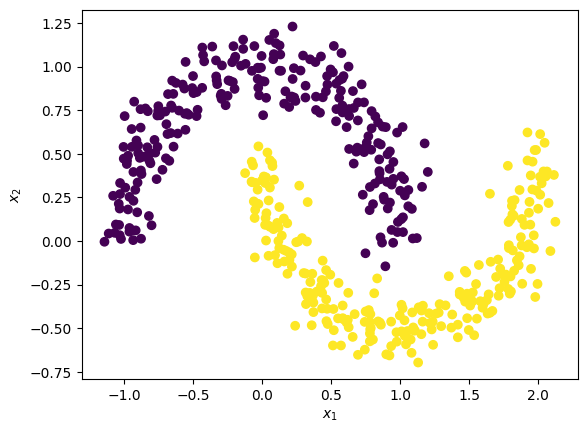

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, label=y)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

Estimated no. of clusters: 1
Estimated no. of noise points: 0
v_measure = 0.0


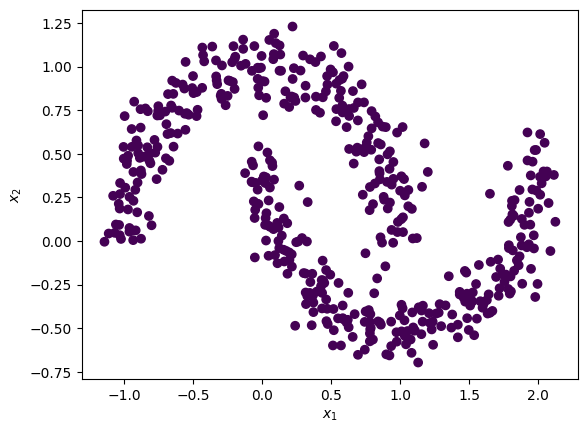

In [ ]:
dbscan_cluster1 = DBSCAN(eps=0.5, min_samples=5)
dbscan_cluster1.fit(X)

# Visualizing DBSCAN
plt.scatter(X[:, 0],
            X[:, 1],
            c=dbscan_cluster1.labels_,
            label=y)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# Number of Clusters
labels=dbscan_cluster1.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster1.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))


Estimated no. of clusters: 3
Estimated no. of noise points: 24
v_measure = 0.7088827090758547
silhouette_score = 0.2170231144722666


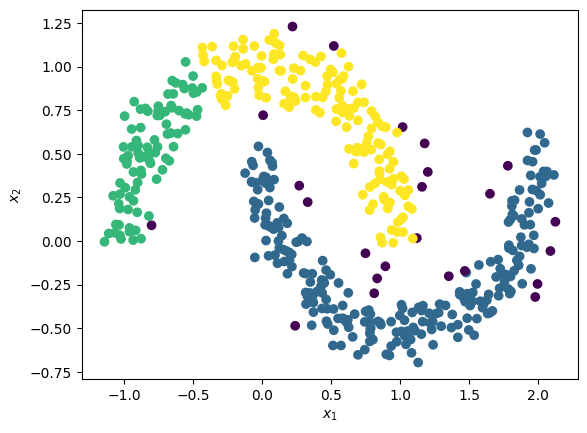

In [ ]:
dbscan_cluster = DBSCAN(eps=0.1, min_samples=4)
dbscan_cluster.fit(X)

# Visualizing DBSCAN
plt.scatter(X[:, 0],
X[:, 1],
c=dbscan_cluster.labels_,
label=y)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# Number of Clusters
labels=dbscan_cluster.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

# Calculating silhouette_score
print('silhouette_score =', silhouette_score(X, labels))

In [ ]:
#The larger the data set, the larger the value of MinPts should be
#If the data set is noisier, choose a larger value of MinPts
#Generally, MinPts should be greater than or equal to the dimensionality of the data set
#For 2-dimensional data, use DBSCAN’s default value of MinPts = 4 (or 5) (Ester et al., 1996).
#If your data has more than 2 dimensions, choose MinPts = 2*dim, where dim= the dimensions of your data set (Sander et al., 1998).

In [ ]:
from sklearn.neighbors import NearestNeighbors

nearest_neighbors = NearestNeighbors(n_neighbors=4)
neighbors = nearest_neighbors.fit(df)

distances, indices = neighbors.kneighbors(df)
distances = np.sort(distances[:,3], axis=0)

Text(0, 0.5, 'Distance')

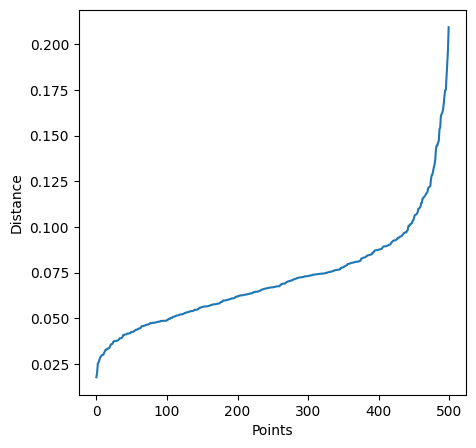

In [ ]:
fig = plt.figure(figsize=(5, 5))
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("Distance")

0.09703933221829349


<Figure size 500x500 with 0 Axes>

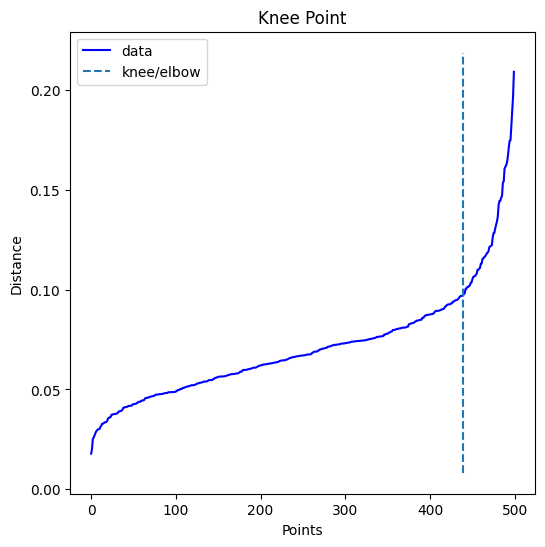

In [ ]:
from kneed import KneeLocator

i = np.arange(len(distances))
knee = KneeLocator(i, distances, S=1, curve='convex', direction='increasing')

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")

print(distances[knee.knee])

Estimated no. of clusters: 2
Estimated no. of noise points: 9
v_measure = 0.9300517351365147
silhouette_score = 0.11830815593399793


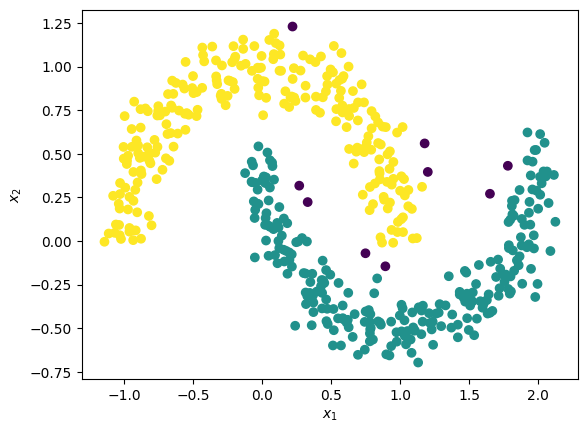

In [ ]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances

dbscan_cluster = DBSCAN(eps=0.13, min_samples=4)
dbscan_cluster.fit(X)

# Visualizing DBSCAN
plt.scatter(X[:, 0],
X[:, 1],
c=dbscan_cluster.labels_,
label=y)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# Number of Clusters
labels=dbscan_cluster.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

# Calculating silhouette_score
print('silhouette_score =', silhouette_score(X, labels))

In [ ]:
#Sporedba so K-means

v_measure = 0.20844085947427374


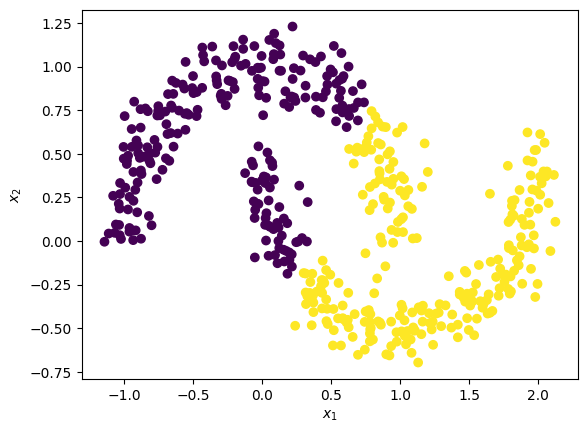

In [ ]:
from sklearn.cluster import KMeans

# K-Means
kmeans = KMeans(n_clusters=2, random_state=1).fit(X)

# we store the cluster labels
labels = kmeans.labels_

plt.scatter(X[:, 0],
X[:, 1],
c=kmeans.labels_,
label=y)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))


In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

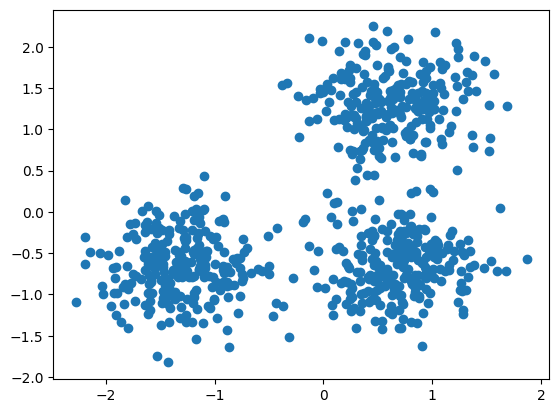

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()


In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


In [ ]:
n_c1_ = list(labels).count(1)
n_c1_

244

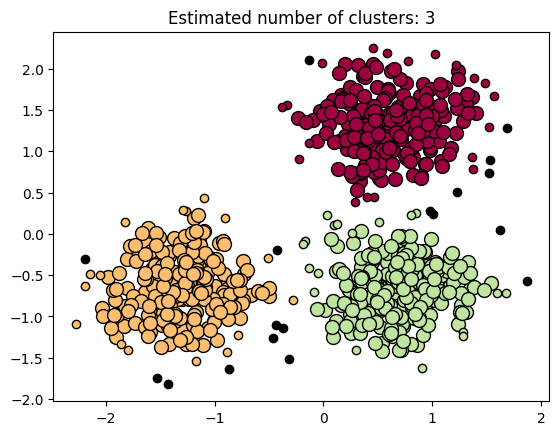

In [ ]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=10,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()